# Warmup Strategies for Active Learning

The **warm-up** phase pre-labels a small set of samples *before* the AL loop starts.  
A well-chosen warm-up can give the classifier a stronger starting point, improving early-cycle performance.

Because no model predictions exist at warm-up time, strategies must rely solely on raw embeddings.

Three built-in warm-up strategies are available:
- `density` -- selects samples surrounded by many neighbours (cluster representatives)
- `random` -- selects samples uniformly at random
- `custom` -- a template you implement in `core/utils/sampling.py`

This notebook also compares all three against a **cold start** (`pretrain_samples=None`).

Set the warm-up method via the `warmup_strategy` parameter of `ActiveLearner`:
```python
learner = ActiveLearner(
    ...,
    warmup_strategy="density",  # 'density' | 'random' | 'custom'
    pretrain_samples=50,
)
```

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 6.380218267440796


## Step 1: Setup Configuration

In [2]:
# AL loop parameters (same as baseline for a fair comparison)
N_CYCLES            = 15
EPOCHS_PER_CYCLE    = 10
BATCH_SIZE          = 32
N_SAMPLES_PER_CYCLE = 50

# Warmup configuration
# Number of samples to pre-label before the AL loop starts.
# Set to None for a cold start (no warmup).
PRETRAIN_SAMPLES: int | None = 50

# Experiments: (label, pretrain_samples, warmup_strategy)
# AL sampling strategy is fixed to 'random' for all so only the warmup varies.
EXPERIMENTS = [
    ("cold_start", None,             "density"),
    ("density",    PRETRAIN_SAMPLES, "density"),
    ("random",     PRETRAIN_SAMPLES, "random"),
    ("custom",     PRETRAIN_SAMPLES, "custom"),   # edit _custom in core/utils/sampling.py
]

# AL sampling strategy -- kept fixed to isolate the warmup effect
SAMPLING_STRATEGY = "random"

print(f"Cycles            : {N_CYCLES}")
print(f"Samples per cycle : {N_SAMPLES_PER_CYCLE}")
print(f"Epochs per cycle  : {EPOCHS_PER_CYCLE}")
print(f"Pretrain samples  : {PRETRAIN_SAMPLES}")
print(f"Experiments       : {[e[0] for e in EXPERIMENTS]}")

Cycles            : 15
Samples per cycle : 50
Epochs per cycle  : 10
Pretrain samples  : 50
Experiments       : ['cold_start', 'density', 'random', 'custom']


## Step 2: Dataset Paths

Adjust for BirdSet subsets (HSN, POW, UHH) or ATBFL as needed.

In [3]:
MODEL_NAME   = "birdnet"       # NOTE: Task 4 datasets use "perch_v2"
DATASET_NAME = "ESC10_BASEAL"  # NOTE: adjust for other datasets

EMBEDDINGS_DIR = PROJECT_ROOT / DATASET_NAME / "embeddings" / MODEL_NAME
LABELS_PATH    = PROJECT_ROOT / DATASET_NAME / "labels.csv"

print(f"Embeddings : {EMBEDDINGS_DIR}")
print(f"Labels     : {LABELS_PATH}")
print(f"Dataset    : {DATASET_NAME}  |  Model: {MODEL_NAME}")

Embeddings : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\embeddings\birdnet
Labels     : c:\Users\bmcewen\Documents\GitHub\BaseAL\ESC10_BASEAL\labels.csv
Dataset    : ESC10_BASEAL  |  Model: birdnet


## Step 3: Run Warmup Experiments

Each experiment shares the same AL sampling strategy and hyperparameters --
only the warm-up configuration varies, isolating its effect on learning curve performance.

In [4]:
results      = {}
all_learners = {}

_dataset_info_printed = False

for exp_name, pretrain, warmup in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"Experiment : {exp_name}")
    print(f"  pretrain_samples  = {pretrain}")
    print(f"  warmup_strategy   = {warmup}")
    print(f"{'='*60}")

    learner = ActiveLearner(
        embeddings_dir=EMBEDDINGS_DIR,
        annotations_path=LABELS_PATH,
        model_name=MODEL_NAME,
        dataset_name=DATASET_NAME,
        learning_rate=0.001,
        sampling_strategy=SAMPLING_STRATEGY,
        warmup_strategy=warmup,
        pretrain_samples=pretrain,
        device="cpu",
        verbose=False,
    )

    if not _dataset_info_printed:
        state = learner.get_state()
        print(f"\n  Dataset : {DATASET_NAME}  |  "
              f"Total: {state['n_labeled'] + state['n_unlabeled']}  |  "
              f"Classes: {state['num_classes']}\n")
        _dataset_info_printed = True

    print(f"  Pre-labeled samples : {len(learner.labeled_indices)}")
    print(f"  {'Cycle':>5}  {'Labelled':>8}  {'mAP':>8}  {'AULC':>8}  {'Time':>7}")
    print(f"  {'-'*46}")

    history = []
    for cycle in range(N_CYCLES):
        if len(learner.unlabeled_indices) == 0:
            break
        t0 = time.time()
        selected = learner.sample(n_samples=N_SAMPLES_PER_CYCLE)
        learner.add_samples(selected)
        metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)
        history.append(metrics)
        print(f"  {cycle + 1:>5}  {metrics['n_labeled']:>8}  "
              f"{metrics['mAP']:>8.4f}  {metrics['aulc_mAP']:>8.4f}  "
              f"{time.time() - t0:>6.2f}s")

    results[exp_name]      = history
    all_learners[exp_name] = learner

    if history:
        final = history[-1]
        print(f"\n  Final mAP  : {final['mAP']:.4f}")
        print(f"  Final AULC : {final['aulc_mAP']:.4f}")


Experiment : cold_start
  pretrain_samples  = None
  warmup_strategy   = density

  Dataset : ESC10_BASEAL  |  Total: 640  |  Classes: 10

  Pre-labeled samples : 0
  Cycle  Labelled       mAP      AULC     Time
  ----------------------------------------------
      1        50    0.8286    0.4143    0.14s


c:\Users\bmcewen\Documents\GitHub\BaseAL\core\active_learner.py:730: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  batch = torch.from_numpy(self.embeddings[start:start + bs]).to(self.device)


      2       100    0.8926    0.6375    0.15s
      3       150    0.9191    0.7269    0.17s
      4       200    0.9185    0.7749    0.23s
      5       250    0.9179    0.8036    0.28s
      6       300    0.9164    0.8225    0.34s
      7       350    0.9171    0.8360    0.37s
      8       400    0.9298    0.8469    0.44s
      9       450    0.9323    0.8562    0.61s
     10       500    0.9307    0.8638    0.91s
     11       550    0.9364    0.8701    0.88s
     12       600    0.9277    0.8753    0.93s
     13       640    0.9256    0.8785    0.98s

  Final mAP  : 0.9256
  Final AULC : 0.8785

Experiment : density
  pretrain_samples  = 50
  warmup_strategy   = density
  Pre-labeled samples : 50
  Cycle  Labelled       mAP      AULC     Time
  ----------------------------------------------


c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bmcewen\Documents\GitHub\BaseAL\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\bmcewen\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\subprocess.py", l

      1       100    0.8994    0.4497    0.16s
      2       150    0.8978    0.5993    0.16s
      3       200    0.8918    0.6732    0.22s
      4       250    0.9231    0.7200    0.26s
      5       300    0.9250    0.7540    0.31s
      6       350    0.9409    0.7796    0.34s
      7       400    0.9406    0.7997    0.39s
      8       450    0.9373    0.8152    0.56s
      9       500    0.9465    0.8279    1.03s
     10       550    0.9419    0.8384    1.05s
     11       600    0.9397    0.8470    1.03s
     12       640    0.9131    0.8519    1.10s

  Final mAP  : 0.9131
  Final AULC : 0.8519

Experiment : random
  pretrain_samples  = 50
  warmup_strategy   = random
  Pre-labeled samples : 50
  Cycle  Labelled       mAP      AULC     Time
  ----------------------------------------------
      1       100    0.8927    0.4464    0.14s
      2       150    0.9287    0.6012    0.17s
      3       200    0.9434    0.6849    0.23s
      4       250    0.9453    0.7368    0.27s
     

core.utils.sampling - WARNING - Custom warmup not implemented, falling back to density sampling


     12       640    0.9143    0.8514    1.10s

  Final mAP  : 0.9143
  Final AULC : 0.8514

Experiment : custom
  pretrain_samples  = 50
  warmup_strategy   = custom
  Pre-labeled samples : 50
  Cycle  Labelled       mAP      AULC     Time
  ----------------------------------------------
      1       100    0.7953    0.3976    0.17s
      2       150    0.8976    0.5472    0.21s
      3       200    0.8752    0.6320    0.27s
      4       250    0.9121    0.6844    0.26s
      5       300    0.9251    0.7234    0.34s
      6       350    0.8998    0.7504    0.33s
      7       400    0.9069    0.7695    0.42s
      8       450    0.9071    0.7848    0.55s
      9       500    0.9103    0.7972    0.96s
     10       550    0.9113    0.8075    0.97s
     11       600    0.9102    0.8161    1.09s
     12       640    0.9142    0.8221    1.18s

  Final mAP  : 0.9142
  Final AULC : 0.8221


## Step 4: Compare Learning Curves

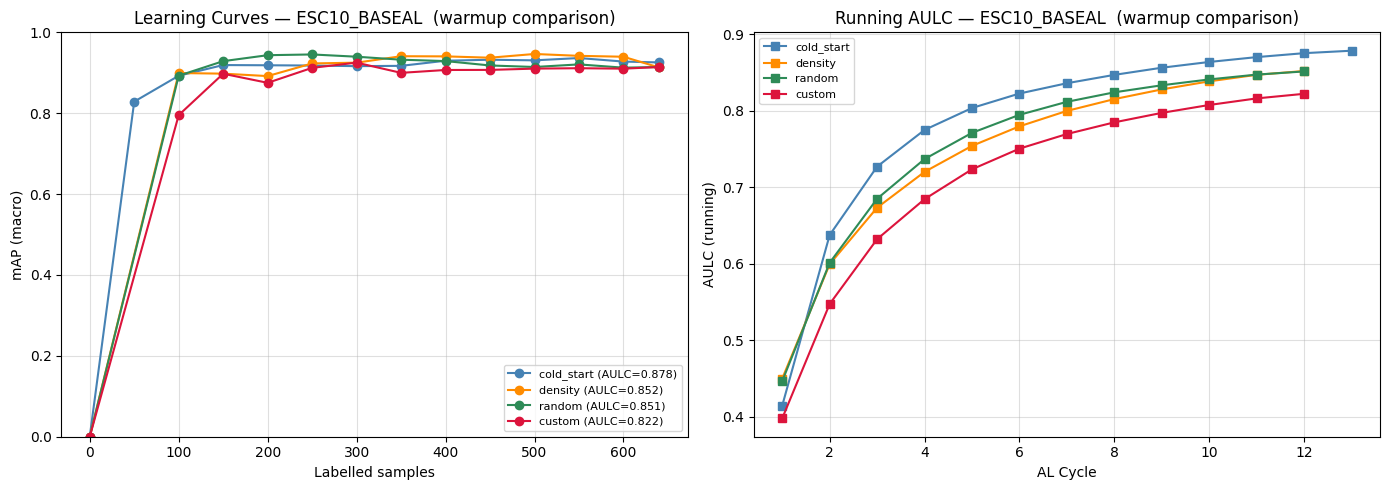


Final results -- warmup strategy comparison
Experiment            Pre-labeled       mAP      AULC
--------------------------------------------------------
cold_start                      0    0.9256    0.8785
density                        50    0.9131    0.8519
random                         50    0.9143    0.8514
custom                         50    0.9142    0.8221


In [5]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (exp_name, pretrain, warmup), color in zip(EXPERIMENTS, colors):
    history = results.get(exp_name, [])
    if not history:
        continue

    n_labeled = [0] + [h['n_labeled'] for h in history]
    mAP_vals  = [0.0] + [h['mAP'] for h in history]
    aulc_vals = [h['aulc_mAP'] for h in history]
    cycles    = list(range(1, len(history) + 1))

    final_aulc = history[-1]['aulc_mAP']
    label = f"{exp_name} (AULC={final_aulc:.3f})"

    axes[0].plot(n_labeled, mAP_vals, marker='o', color=color, label=label)
    axes[1].plot(cycles, aulc_vals, marker='s', color=color, label=exp_name)

axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curves -- {DATASET_NAME}  (warmup comparison)')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title(f'Running AULC -- {DATASET_NAME}  (warmup comparison)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal results -- warmup strategy comparison")
print(f"{'Experiment':<20}  {'Pre-labeled':>11}  {'mAP':>8}  {'AULC':>8}")
print("-" * 56)
for exp_name, pretrain, warmup in EXPERIMENTS:
    history = results.get(exp_name, [])
    if history:
        final = history[-1]
        print(f"{exp_name:<20}  {pretrain or 0:>11}  "
              f"{final['mAP']:>8.4f}  {final['aulc_mAP']:>8.4f}")

## Step 5: Implementing a Custom Warmup Strategy

Edit the `_custom` method in [core/utils/sampling.py](../../core/utils/sampling.py) inside the `WarmupStrategy` class.

The method receives candidate embeddings via `self.embeddings[self.candidate_indices]`
and must return a utility array of shape `(n_candidates,)` -- higher score means higher
priority for initial annotation.

Example -- select the most spread-out samples by average pairwise distance:

```python
def _custom(self) -> np.ndarray:
    from sklearn.metrics.pairwise import euclidean_distances
    X = self.embeddings[self.candidate_indices]
    # Average distance to all other candidates as a spread proxy
    utility = euclidean_distances(X).mean(axis=1)
    return utility.astype(np.float32)
```

Then use it in `ActiveLearner`:

```python
learner = ActiveLearner(
    embeddings_dir=EMBEDDINGS_DIR,
    annotations_path=LABELS_PATH,
    warmup_strategy="custom",
    pretrain_samples=50,
    ...
)
```

## Notes

- The warm-up budget is **separate** from the AL budget. With `pretrain_samples=50` and
  `N_SAMPLES_PER_CYCLE=50`, the total annotation budget after `N_CYCLES=15` cycles is
  `50 + 15x50 = 800`.
- AULC is computed from cycle 1 onwards; the warm-up samples are not counted as a cycle,
  but they are included in `n_labeled` from cycle 1.
- Setting `pretrain_samples=None` (or `0`) disables warm-up entirely (cold start).
- The `warmup_strategy` field is included in exported YAML files so your choice is
  recorded in any submission.
- For challenge submissions, document your warmup strategy and sample count in your
  method description.